In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
import warnings; warnings.filterwarnings("ignore")
from tensorflow.keras.models import Sequential







# Google Drive Mount (Specific to Google Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
def prepped():
    df = pd.read_csv('/content/drive/MyDrive/TIME SERIES ANALYSIS/btcusd_1-min_data.csv')
    df['Datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
    df.set_index('Datetime', inplace=True)
    df.drop(columns=['Timestamp', 'High', 'Low', 'Open', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price'], errors='ignore', inplace=True)
    df = df[['Close']]
    # Resamplinf to daily frequency, taking the last observed value of the day.
    # Added .dropna() to handle days with no data after resampling.
    df = df.resample('D').last().dropna()
    return df

df = prepped()

# Time Resampling (daily already done in prepped())
df_daily = df

# Monthly resampling: Using .last() for consistency with daily closing prices.
# If the intent is to analyze average monthly prices, .mean() would be appropriate.
df_monthly = df.resample('M').last().dropna()

In [23]:
#to get the dates
print(f"My data starts on: {df.index.min().date()}")
print(f"My data ends on: {df.index.max().date()}")

My data starts on: 2012-01-01
My data ends on: 2025-05-23


--- Descriptive Statistics for Daily Close Price ---
count      4892.000000
mean      17805.922112
std       24702.683839
min           4.380000
25%         426.677500
50%        6674.735000
75%       27666.000000
max      111743.000000
Name: Close, dtype: float64

Number of missing values: 0


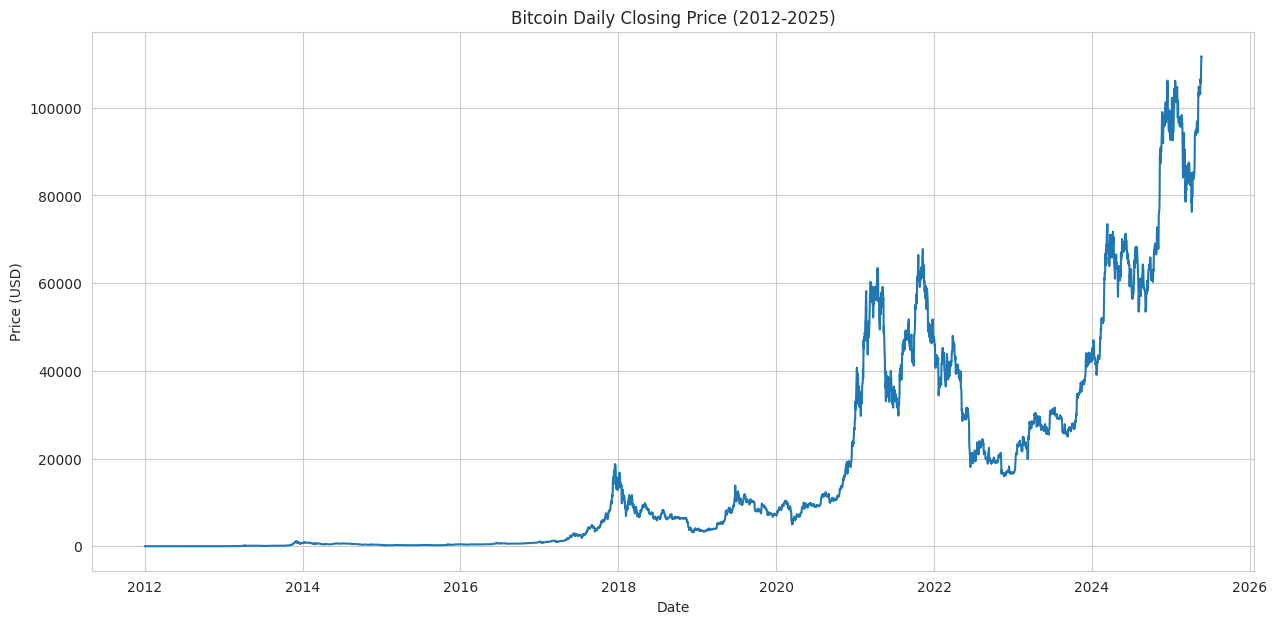

In [24]:
# Set a simple plot style
sns.set_style("whitegrid")

# 1. Get the basic stats and print them
print("--- Descriptive Statistics for Daily Close Price ---")
print(df_daily['Close'].describe())
# 2. Double-check for any null values
print(f"\nNumber of missing values: {df_daily.isnull().sum().sum()}")


# 3. Plot the daily closing price
plt.figure(figsize=(15, 7))
plt.plot(df_daily.index, df_daily['Close'])
plt.title('Bitcoin Daily Closing Price (2012-2025)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

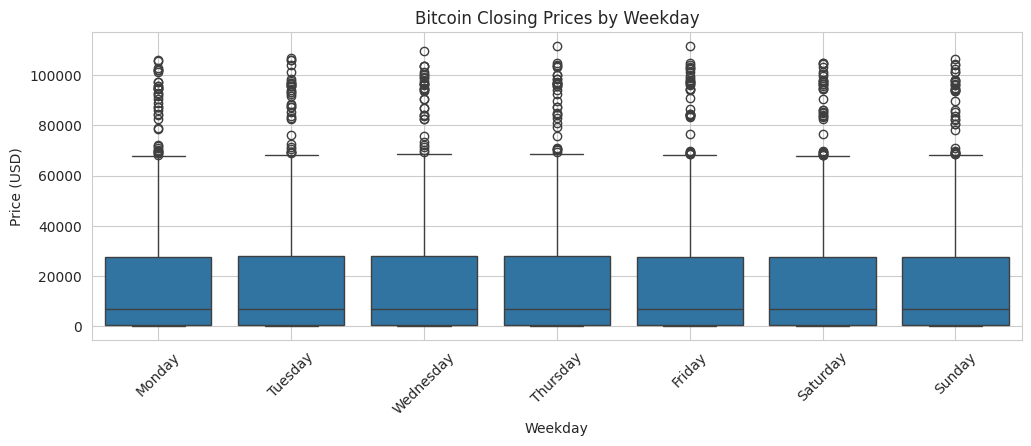

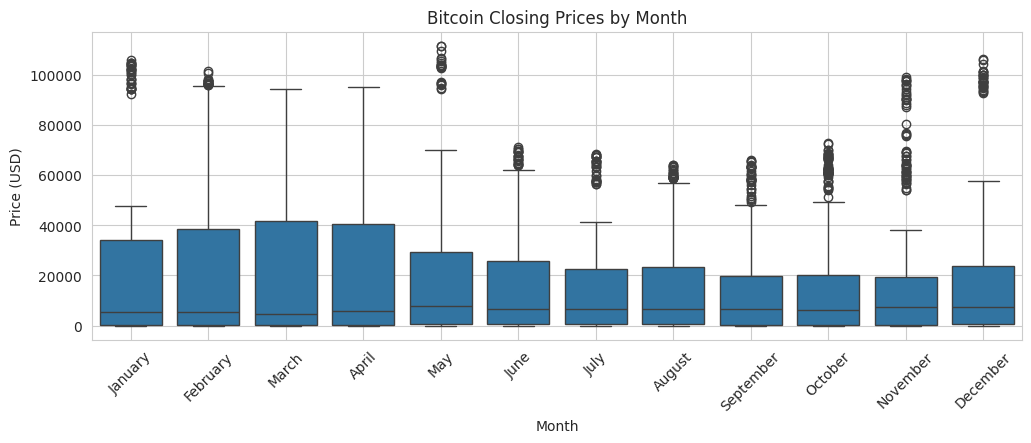

In [25]:
# Add weekday and month features
df_daily['Weekday'] = df_daily.index.day_name()
df_daily['Month'] = df_daily.index.month_name()

# --- Average Price by Weekday ---
plt.figure(figsize=(12,4))
sns.boxplot(data=df_daily, x='Weekday', y='Close', order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Bitcoin Closing Prices by Weekday')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# --- Average Price by Month ---
plt.figure(figsize=(12,4))
sns.boxplot(data=df_daily, x='Month', y='Close', order=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'])
plt.title('Bitcoin Closing Prices by Month')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


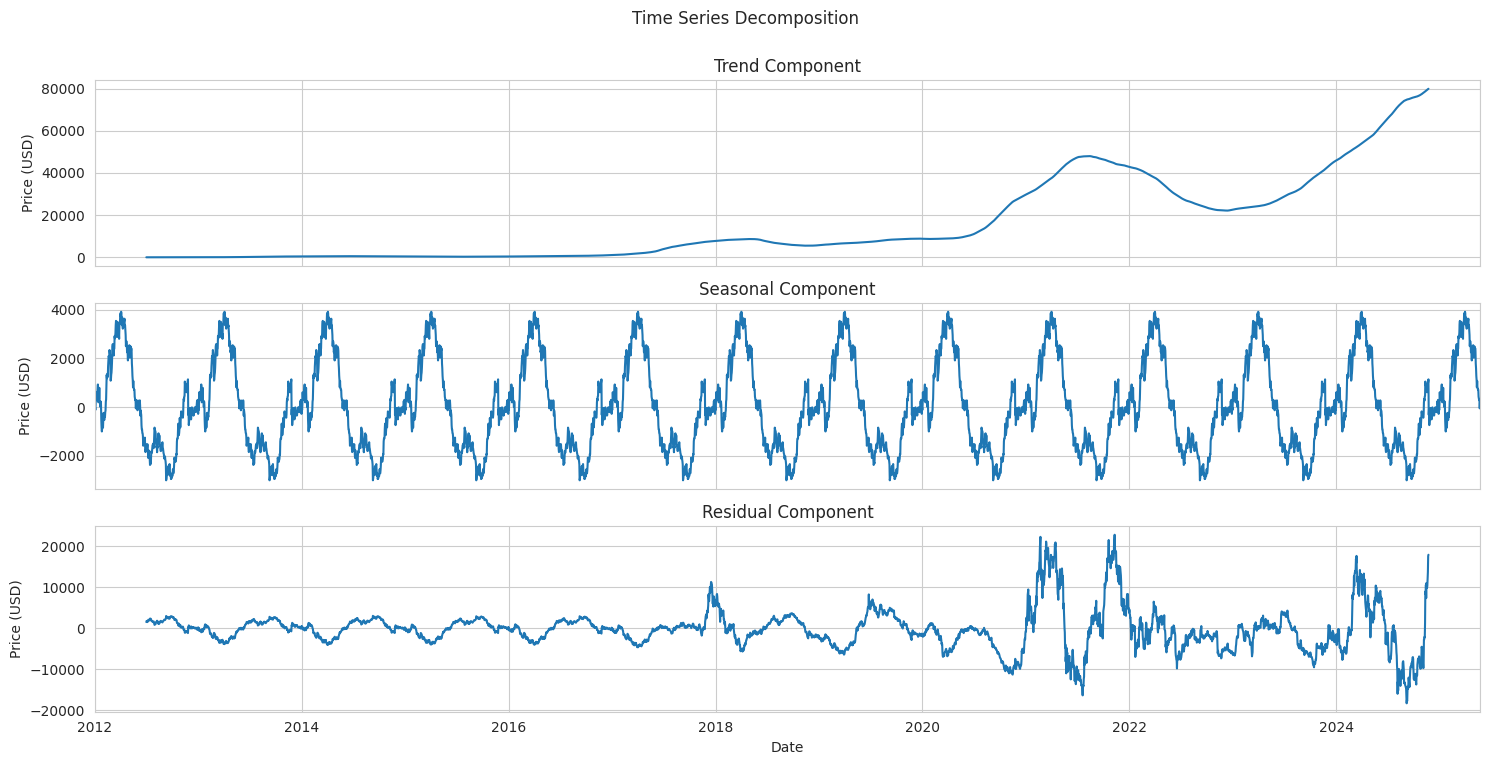

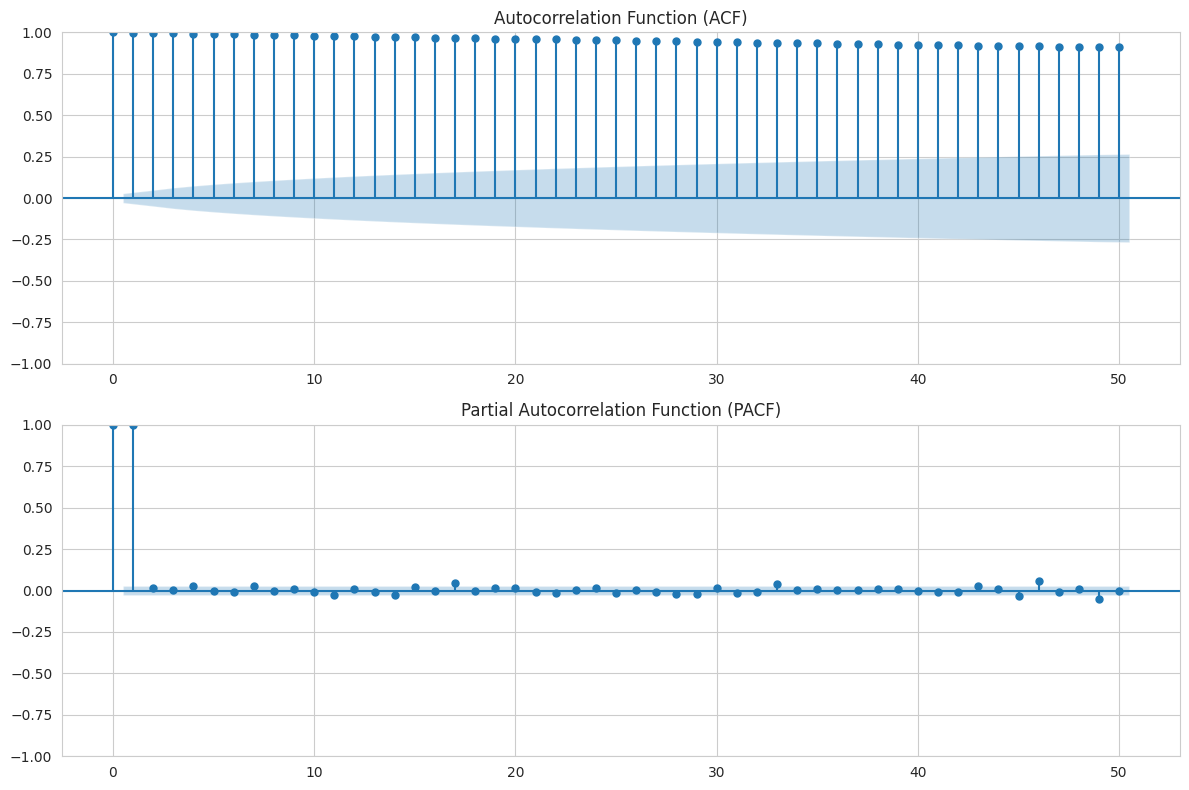

--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: 0.6845021914996269
p-value: 0.9895234551204807

Critical Values:
	1%: -3.4316962463523613
	5%: -2.862134891540868
	10%: -2.5670866621365307

If the p-value is > 0.05, we cannot reject the null hypothesis (that the series is non-stationary).


In [26]:
# 1. Calculate the decomposition components
decomposition = seasonal_decompose(df_daily['Close'], model='additive', period=365)

# 2. Create a custom plot showing only Trend, Seasonality, and Residuals
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
decomposition.trend.plot(ax=ax1)
ax1.set_title('Trend Component')
ax1.set_ylabel('Price (USD)')

decomposition.seasonal.plot(ax=ax2)
ax2.set_title('Seasonal Component')
ax2.set_ylabel('Price (USD)')

decomposition.resid.plot(ax=ax3)
ax3.set_title('Residual Component')
ax3.set_ylabel('Price (USD)')
ax3.set_xlabel('Date')

plt.suptitle('Time Series Decomposition', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# --- ACF/PACF PLOT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_daily['Close'], lags=50, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

plot_pacf(df_daily['Close'], lags=50, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()


# --- STATIONARITY TEST
print('--- Augmented Dickey-Fuller Test Results ---')
adf_result = adfuller(df_daily['Close'])
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print('\nCritical Values:')
for key, value in adf_result[4].items():
    print(f'\t{key}: {value}')
print('\nIf the p-value is > 0.05, we cannot reject the null hypothesis (that the series is non-stationary).')

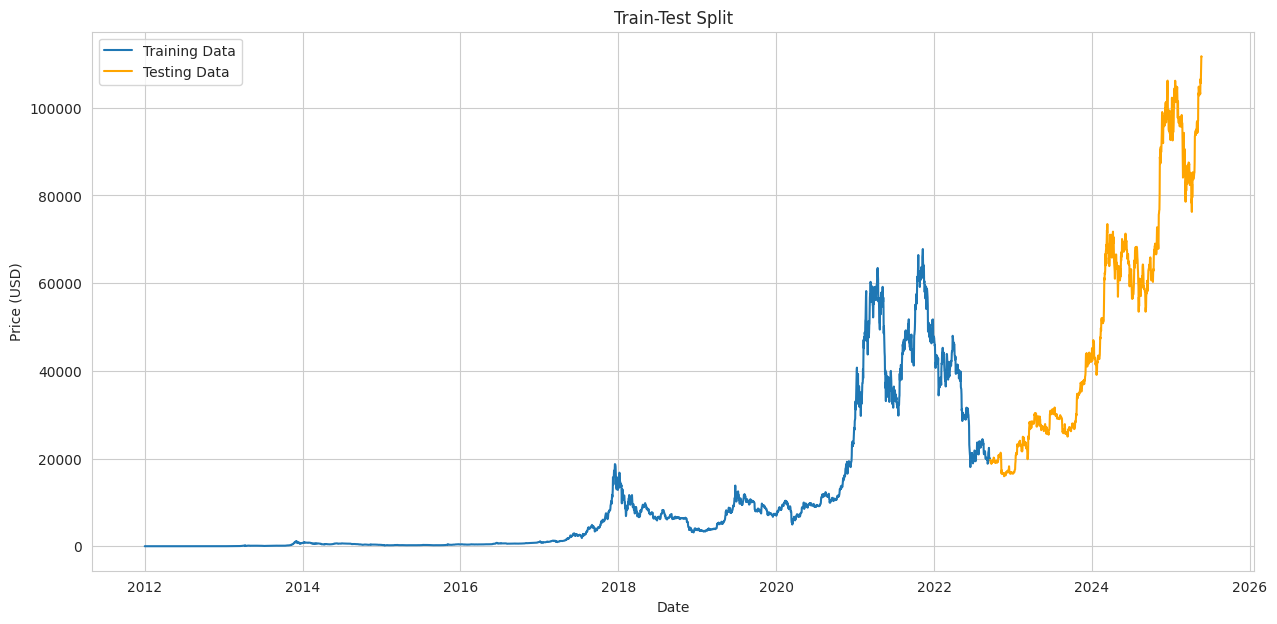

Training data runs from 2012-01-01 to 2022-09-17
Testing data runs from 2022-09-18 to 2025-05-23
The testing set contains 979 days.


In [27]:
# Calculate the split point
split_point = int(len(df_daily) * 0.8)

# Split the data
train_df = df_daily.iloc[:split_point]
test_df = df_daily.iloc[split_point:]

# Plot the split
plt.figure(figsize=(15, 7))
plt.plot(train_df.index, train_df['Close'], label='Training Data')
plt.plot(test_df.index, test_df['Close'], label='Testing Data', color='orange')
plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Print the dates
print(f"Training data runs from {train_df.index.min().date()} to {train_df.index.max().date()}")
print(f"Testing data runs from {test_df.index.min().date()} to {test_df.index.max().date()}")
print(f"The testing set contains {len(test_df)} days.")

Fitting the fast ARIMA(1,1,1) model...
Model fitting complete. Now generating forecasts.


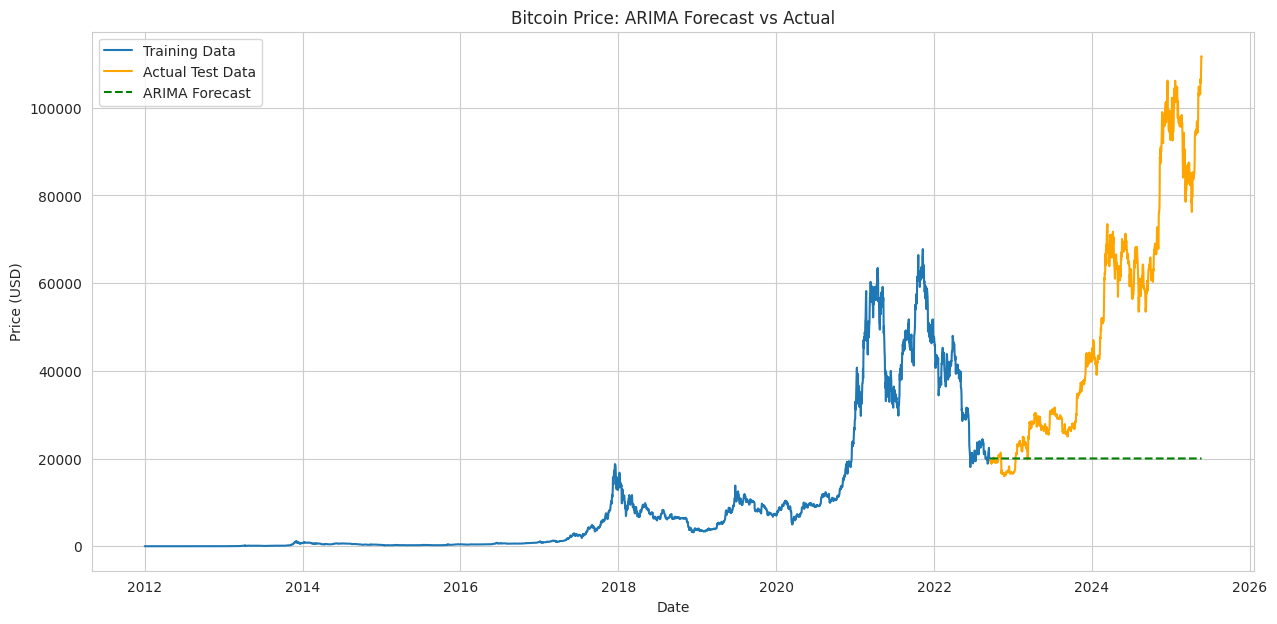

In [28]:
# Define our simpler, non-seasonal model order
my_order = (1, 1, 1)

print("Fitting the fast ARIMA(1,1,1) model...")

# Create and fit the model.
model = ARIMA(train_df['Close'], order=my_order)

# Fitting the model will return a results object
model_fit = model.fit()

print("Model fitting complete. Now generating forecasts.")

# Get forecasts for the same time period as the test set
forecast = model_fit.get_forecast(steps=len(test_df)).predicted_mean

# Assign the correct index to the forecast
forecast.index = test_df.index

# Plot the results
plt.figure(figsize=(15, 7))
plt.plot(train_df['Close'], label='Training Data')
plt.plot(test_df['Close'], label='Actual Test Data', color='orange')
plt.plot(forecast, label='ARIMA Forecast', color='green', linestyle='--')
plt.title('Bitcoin Price: ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [29]:
#the Mean Absolute Error
mae_arima = mean_absolute_error(test_df['Close'], forecast)

print(f"ARIMA Model Mean Absolute Error (MAE): ${mae_arima:,.2f}")

ARIMA Model Mean Absolute Error (MAE): $31,453.12


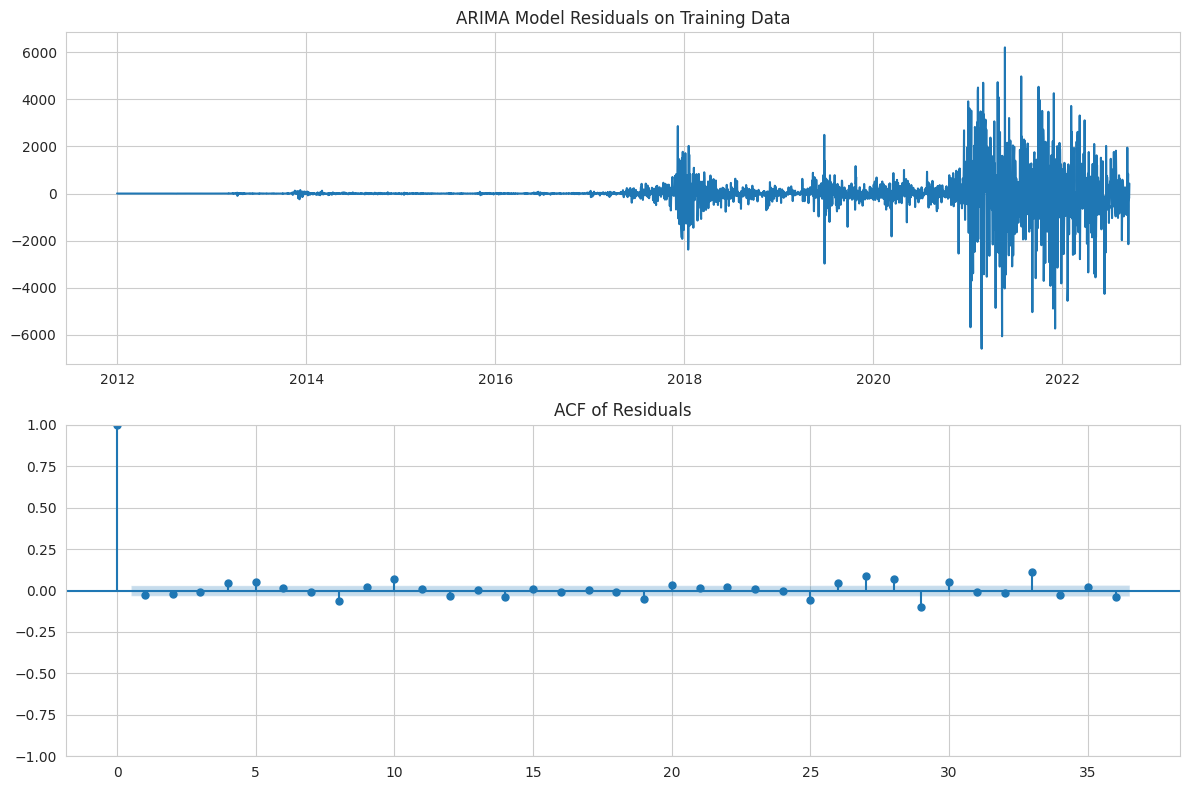

In [30]:
# Get the model residuals
residuals = model_fit.resid

# Plot the residuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(residuals)
ax1.set_title('ARIMA Model Residuals on Training Data')

# Plot the ACF of the residuals
plot_acf(residuals, ax=ax2)
ax2.set_title('ACF of Residuals')

plt.tight_layout()
plt.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpi_npb87x/hp0fa6hm.json


Fitting the Prophet model...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpi_npb87x/3g36iiy5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=36460', 'data', 'file=/tmp/tmpi_npb87x/hp0fa6hm.json', 'init=/tmp/tmpi_npb87x/3g36iiy5.json', 'output', 'file=/tmp/tmpi_npb87x/prophet_modely0y1bt8g/prophet_model-20250624143116.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:31:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:31:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Model fitting complete.
Plotting the forecast...


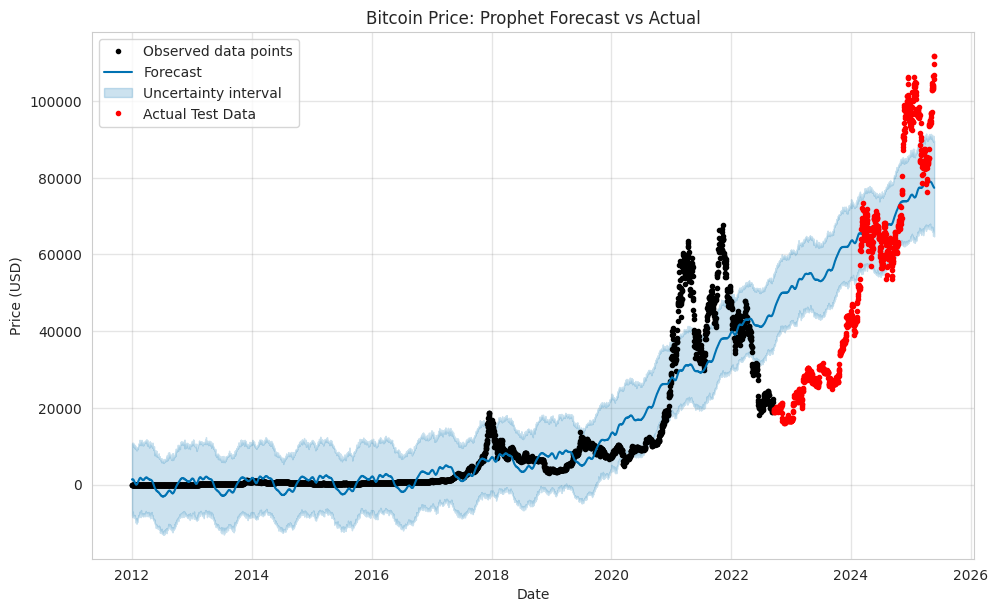

In [31]:
# --- Data Preparation ---
# Prophet requires the dataframe to have specific column names: 'ds' for dates and 'y' for values.
prophet_train_df = train_df.reset_index()
prophet_train_df = prophet_train_df.rename(columns={'Datetime': 'ds', 'Close': 'y'})

# --- Model Fitting ---
print("Fitting the Prophet model...")
# We instantiate Prophet. It will automatically detect yearly and weekly seasonality.
model_prophet = Prophet()
model_prophet.fit(prophet_train_df)
print("Model fitting complete.")

# --- Forecasting ---
# Create a dataframe for future dates to forecast on.
future = model_prophet.make_future_dataframe(periods=len(test_df))
forecast_prophet = model_prophet.predict(future)

# --- Plotting ---
print("Plotting the forecast...")
fig1 = model_prophet.plot(forecast_prophet)
# Add the actual test data to the plot for comparison
plt.plot(test_df.index, test_df['Close'], '.r', label='Actual Test Data')
plt.title('Bitcoin Price: Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [32]:
# The forecast_prophet dataframe contains predictions for both training and testing periods.
# We need to grab only the predictions that correspond to our test set dates.
prophet_forecast_on_test = forecast_prophet.set_index('ds').loc[test_df.index]

#the Mean Absolute Error
mae_prophet = mean_absolute_error(test_df['Close'], prophet_forecast_on_test['yhat'])

print(f"Prophet Model Mean Absolute Error (MAE): ${mae_prophet:,.2f}")

Prophet Model Mean Absolute Error (MAE): $19,286.26


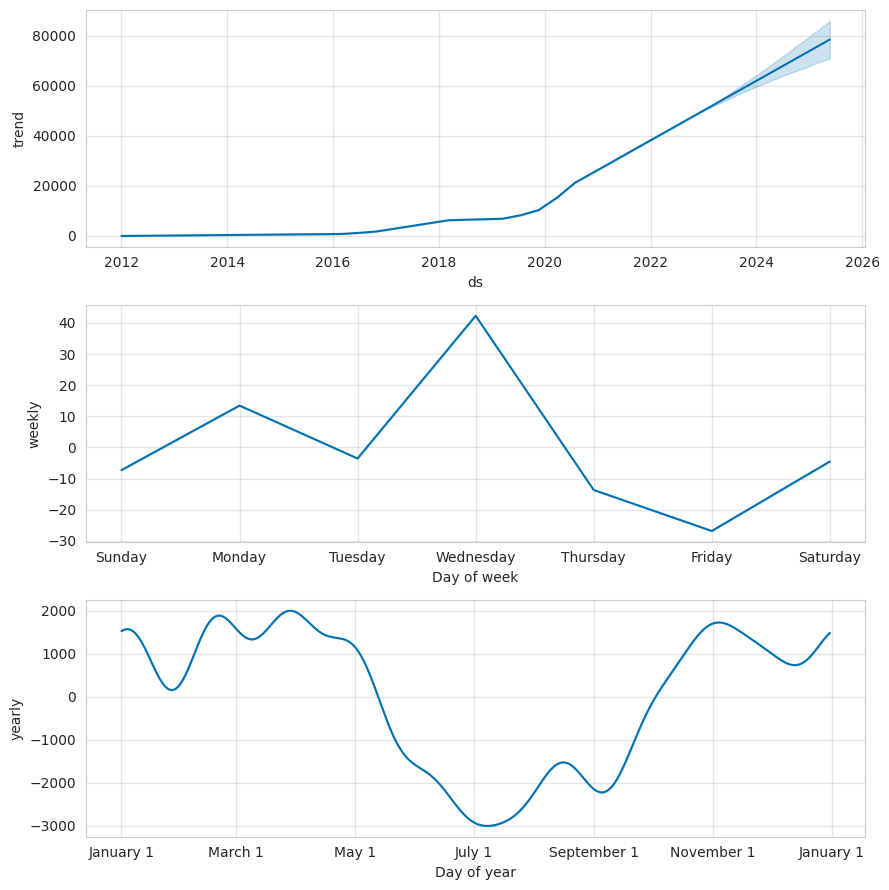

In [33]:
# Use Prophet's built-in function to plot the forecast components
fig2 = model_prophet.plot_components(forecast_prophet)
plt.show()

In [34]:
# --- 1. Scaling ---
# Create a scaler and fit it to the training data
scaler = MinMaxScaler(feature_range=(0, 1))
# We only use the training data to fit the scaler to avoid data leakage from the test set
scaled_train_data = scaler.fit_transform(train_df[['Close']])

# --- 2. Sequencing ---
# We will use the last 60 days of data to predict the 61st day
sequence_length = 60
X_train = []
y_train = []

for i in range(sequence_length, len(scaled_train_data)):
    X_train.append(scaled_train_data[i-sequence_length:i, 0])
    y_train.append(scaled_train_data[i, 0])

# Convert to numpy arrays, which is what the LSTM model will expect
X_train, y_train = np.array(X_train), np.array(y_train)

# The LSTM needs data in a 3D format: [samples, timesteps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print("--- LSTM Data Preparation Complete ---")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

--- LSTM Data Preparation Complete ---
Shape of X_train: (3853, 60, 1)
Shape of y_train: (3853,)


In [35]:
# --- 1. Build the LSTM Model ---
model_lstm = Sequential()

# First LSTM layer with Dropout
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dropout(0.2))

# Second LSTM layer with Dropout
model_lstm.add(LSTM(units=50, return_sequences=False))
model_lstm.add(Dropout(0.2))

# Dense output layer
model_lstm.add(Dense(units=1))

# --- 2. Compile the Model ---
print("Compiling the LSTM model...")
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
print("Model compilation complete.")

# --- 3. Train the Model ---
print("\nStarting model training... This will take a few minutes.")
# We train the model on our prepared training data for 25 epochs.
# An epoch is one full run through the data.
history = model_lstm.fit(X_train, y_train, epochs=25, batch_size=32)
print("\nModel training complete.")

Compiling the LSTM model...
Model compilation complete.

Starting model training... This will take a few minutes.
Epoch 1/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 0.0171
Epoch 2/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 0.0016
Epoch 3/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 0.0014
Epoch 4/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step - loss: 0.0012
Epoch 5/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.0011
Epoch 6/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0011
Epoch 7/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0011
Epoch 8/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 8.6644e-04
Epoch 9/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 9.9367e-04
Epoch 10/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 9.6838e-04
Epoch 11/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 7.6683e-04
Epoch 12/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 7.5329e-04
Epoch 13/25
121/121 ━━━━━━━━━━━━━━━━━━━━ 10

Making predictions with the LSTM model...
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Predictions complete.


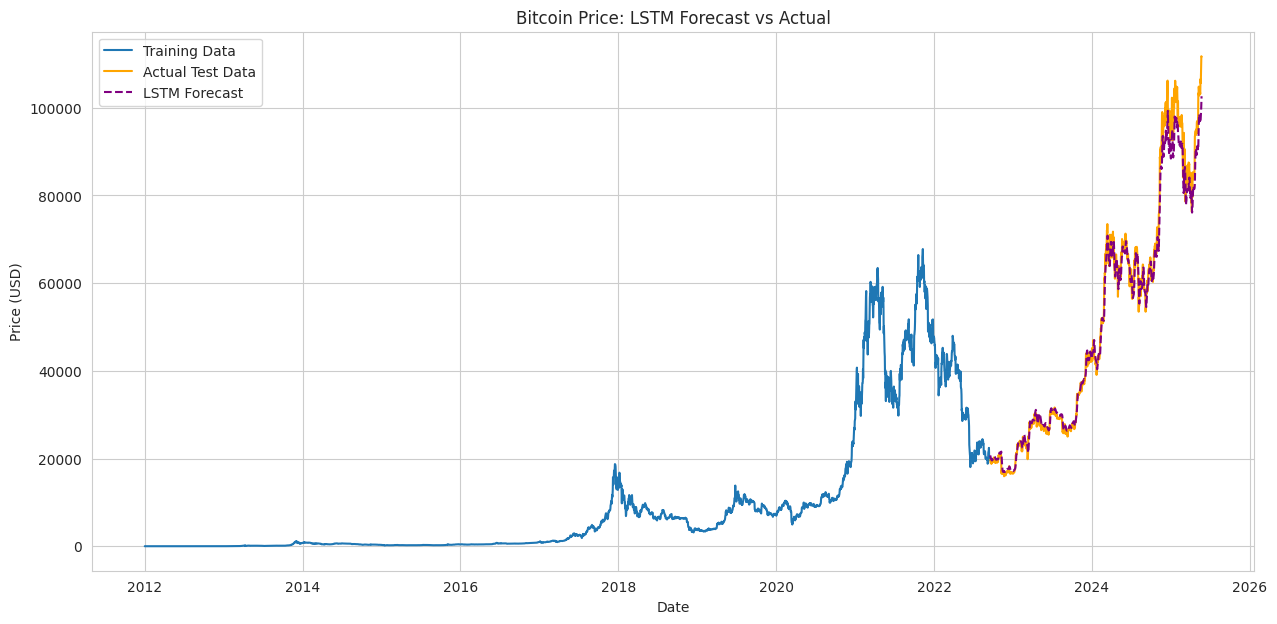

In [36]:
# --- 1. Prepare the test data ---
# We need the last 60 days of the training data to lead into the test data
# THE FIX IS HERE: We specify ['Close'] to only get the numerical price data.
inputs = df_daily['Close'][len(df_daily) - len(test_df) - sequence_length:].values
inputs = inputs.reshape(-1,1)
# Scale the data using the same scaler we fitted on the training data
inputs = scaler.transform(inputs)

# Create the test sequences
X_test = []
for i in range(sequence_length, len(inputs)):
    X_test.append(inputs[i-sequence_length:i, 0])

# Convert to a numpy array and reshape for the model
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# --- 2. Make predictions ---
print("Making predictions with the LSTM model...")
predicted_price_scaled = model_lstm.predict(X_test)

# --- 3. Inverse scale the predictions ---
# We use scaler.inverse_transform to get the prices back in USD
predicted_price = scaler.inverse_transform(predicted_price_scaled)
print("Predictions complete.")

# --- 4. Plot the results ---
# Create a dataframe with the predicted prices for easy plotting
lstm_forecast = pd.DataFrame(predicted_price, columns=['Forecast'])
lstm_forecast.index = test_df.index

plt.figure(figsize=(15, 7))
plt.plot(train_df['Close'], label='Training Data')
plt.plot(test_df['Close'], label='Actual Test Data', color='orange')
plt.plot(lstm_forecast['Forecast'], label='LSTM Forecast', color='purple', linestyle='--')
plt.title('Bitcoin Price: LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [37]:
# Calculate the Mean Absolute Error for the LSTM forecast
mae_lstm = mean_absolute_error(test_df['Close'], lstm_forecast['Forecast'])

print(f"LSTM Model Mean Absolute Error (MAE): ${mae_lstm:,.2f}")

LSTM Model Mean Absolute Error (MAE): $1,946.31


In [18]:
#from statsmodels.tsa.statespace.sarimax import SARIMAX
#import matplotlib.pyplot as plt

## Define our manually selected model order
## Order (p,d,q), Seasonal Order (P,D,Q,m)
#my_order = (1, 1, 1)
#my_seasonal_order = (1, 0, 1, 365)

#print("Fitting the SARIMA(1,1,1)(1,0,1,365) model... This may still take some time.")

## Create and fit the model
#model = SARIMAX(train_df['Close'],
#                order=my_order,
#                seasonal_order=my_seasonal_order,
#                enforce_stationarity=False,
#                enforce_invertibility=False)

## Fitting the model will return a results object
#model_fit = model.fit(disp=False) # disp=False turns off verbose output

#print("Model fitting complete. Now generating forecasts.")

## Get forecasts for the same time period as the test set
## The dynamic=False argument means forecasts are made one step at a time
#forecast_object = model_fit.get_forecast(steps=len(test_df))

# Extract the predicted mean values
#forecast = forecast_object.predicted_mean

## Create a pandas series with the same index as the test set
#forecast.index = test_df.index

## Plot the results
#plt.figure(figsize=(15, 7))
#plt.plot(train_df['Close'], label='Training Data')
#plt.plot(test_df['Close'], label='Actual Test Data', color='orange')
#plt.plot(forecast, label='SARIMA Forecast', color='green', linestyle='--')
#plt.title('Bitcoin Price: SARIMA Forecast vs Actual')
#plt.xlabel('Date')
#plt.ylabel('Price (USD)')
#plt.legend()
#plt.show()